# Baseliene

In [2]:
results_list = []


--- Training Final Multi-class Model on Combined Dataset of 1279 samples ---
Accuracy: 0.5469, Macro F1: 0.3184
Accuracy: 0.5469
Macro F1 Score: 0.3184
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.10      0.20      0.13        10
           5       0.64      0.58      0.61       130
           6       0.61      0.47      0.53       132
           7       0.51      0.83      0.64        42
           8       0.00      0.00      0.00         5

    accuracy                           0.55       320
   macro avg       0.31      0.35      0.32       320
weighted avg       0.59      0.55      0.56       320



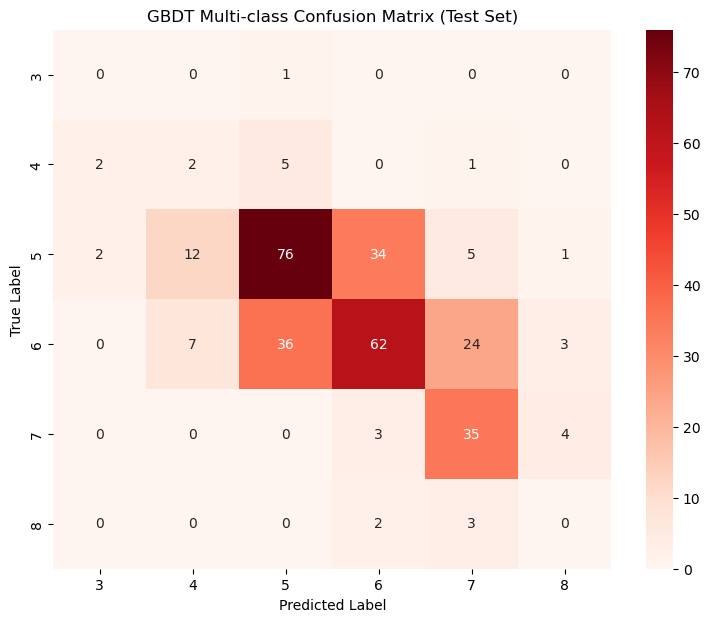

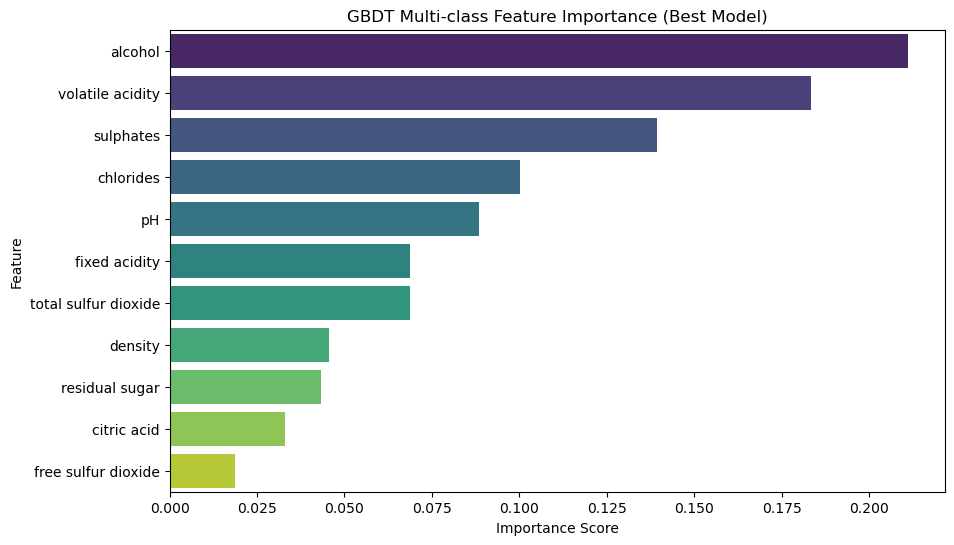

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

df = pd.read_csv("../data/winequality-red_sep.csv") 
X = df.drop('quality', axis=1)
y_multi = df['quality']

# Train_Val (80%) vs Test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42
)

base_params = {
    'gbdt__n_estimators': 300, 
    'gbdt__max_depth': 4, 
    'gbdt__learning_rate': 0.01,
}


X_train_final = X_train_val
y_train_final = y_train_val

final_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_final
)

final_gbdt_data = GradientBoostingClassifier(
    n_estimators=base_params['gbdt__n_estimators'],     
    learning_rate=base_params['gbdt__learning_rate'],    
    max_depth=base_params['gbdt__max_depth'],  
    random_state=42
)

print(f"\n--- Training Final Multi-class Model on Combined Dataset of {len(X_train_final)} samples ---")

final_gbdt_data.fit(X_train_final, y_train_final, sample_weight=final_sample_weights)

y_test_pred = final_gbdt_data.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

results_list.append(('processed date + orignal model', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}") 
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('GBDT Multi-class Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
feature_importances = final_gbdt_data.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis', hue='Feature', legend=False)
plt.title('GBDT Multi-class Feature Importance (Best Model)')
plt.xlabel('Importance Score')
plt.show()

# Regularization Parameters


--- Training Final Multi-class Model on Combined Dataset of 1279 samples ---
Accuracy: 0.5781, Macro F1: 0.3408
Accuracy: 0.5781
Macro F1 Score: 0.3408
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.20      0.30      0.24        10
           5       0.68      0.65      0.66       130
           6       0.62      0.49      0.55       132
           7       0.48      0.79      0.59        42
           8       0.00      0.00      0.00         5

    accuracy                           0.58       320
   macro avg       0.33      0.37      0.34       320
weighted avg       0.60      0.58      0.58       320



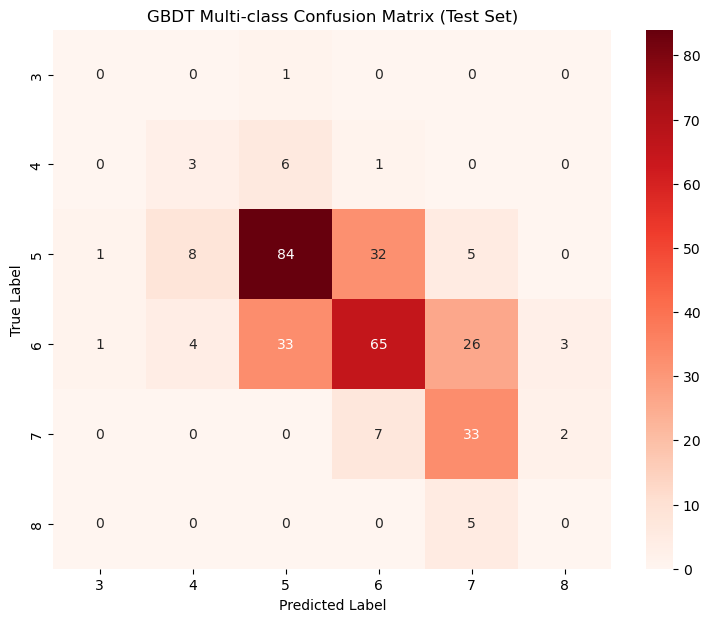

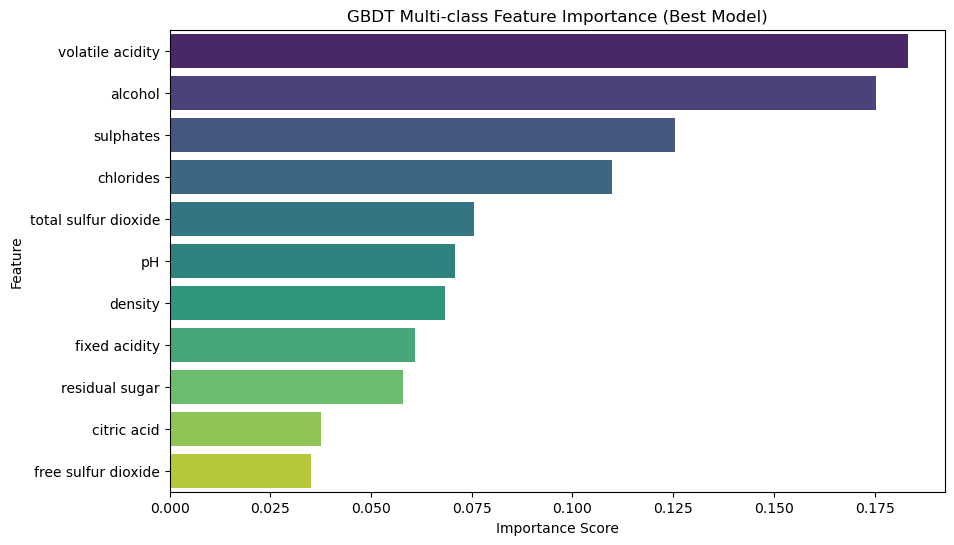

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

df = pd.read_csv("../data/winequality-red_sep.csv") 
X = df.drop('quality', axis=1)
y_multi = df['quality']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42
)

base_params = {
    'gbdt__n_estimators': 300, 
    'gbdt__max_depth': 4, 
    'gbdt__learning_rate': 0.01,
    'gbdt__min_samples_leaf': 3, 
    'gbdt__subsample': 0.8,  
}

X_train_final = X_train_val
y_train_final = y_train_val

final_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_final
)

final_gbdt_data = GradientBoostingClassifier(
    n_estimators=base_params['gbdt__n_estimators'],     
    learning_rate=base_params['gbdt__learning_rate'],    
    max_depth=base_params['gbdt__max_depth'],  
    subsample=base_params['gbdt__subsample'],
    min_samples_leaf=base_params['gbdt__min_samples_leaf'],
    random_state=42
)

print(f"\n--- Training Final Multi-class Model on Combined Dataset of {len(X_train_final)} samples ---")

final_gbdt_data.fit(X_train_final, y_train_final, sample_weight=final_sample_weights)

y_test_pred = final_gbdt_data.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

results_list.append(('Regularization Parameters', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}") 
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

# Confusion Matrix
plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('GBDT Multi-class Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
feature_importances = final_gbdt_data.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis', hue='Feature', legend=False)
plt.title('GBDT Multi-class Feature Importance (Best Model)')
plt.xlabel('Importance Score')
plt.show()

# GridSearchCV

Grid Search Training Set (60%): 959 samples
Final Test Set (20%): 320 samples
Multi-class Label Distribution (60%): quality
3      8
4     29
5    398
6    391
7    124
8      9
Name: count, dtype: int64

--- GBDT Grid Search Started ---
Total Theoretical Candidate Combinations: 243
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

 Grid Search best parameters: {'gbdt__learning_rate': 0.1, 'gbdt__max_depth': 6, 'gbdt__min_samples_leaf': 1, 'gbdt__n_estimators': 500, 'gbdt__subsample': 0.8}

--- Training Final Multi-class Model on Combined Dataset of 1279 samples ---
Accuracy: 0.6719, Macro F1: 0.3387
Accuracy: 0.6719
Macro F1 Score: 0.3387
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.73      0.75      0.74       130
           6       0.64      0.71      0.68       132
           7       0.67      0.57      0.62

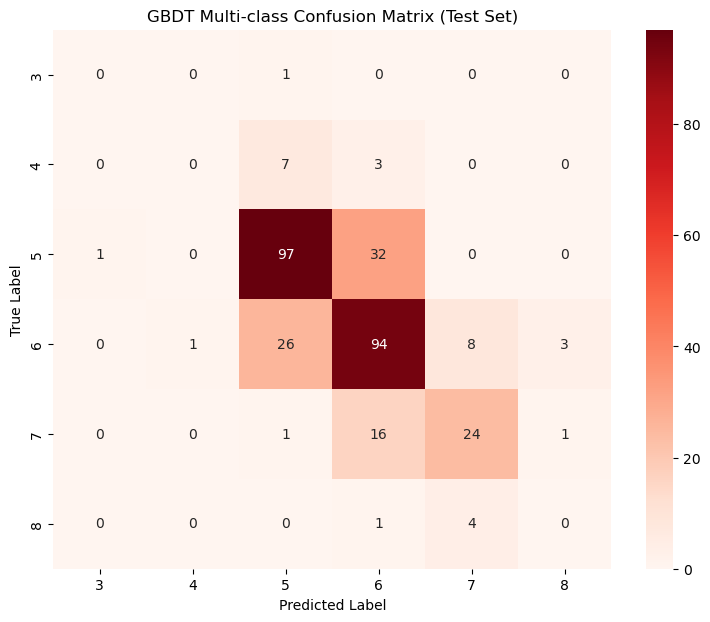

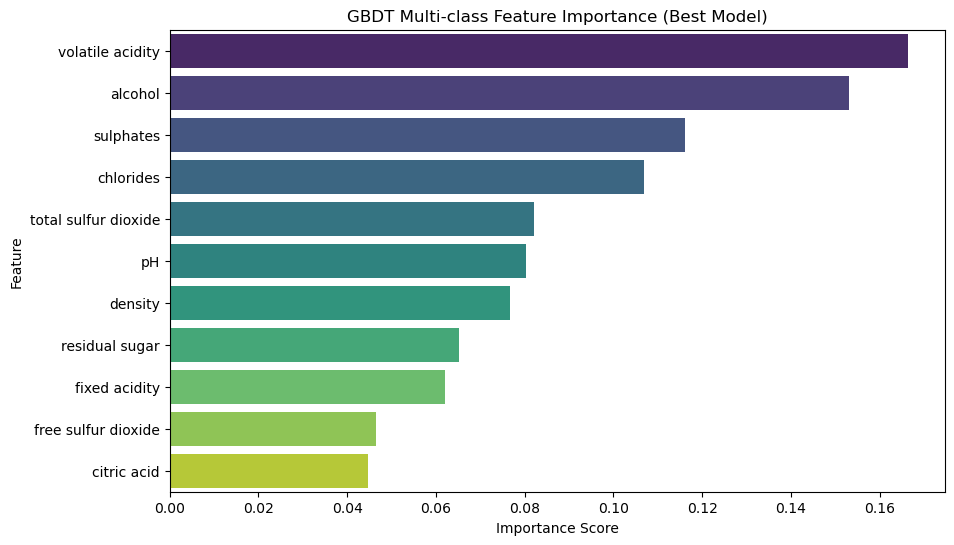

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight



try:
    df = pd.read_csv("../data/winequality-red_sep.csv")
except FileNotFoundError:
    print("ERROR: Please ensure that the path of the data file is correct.")

X = df.drop('quality', axis=1)
y_multi = df['quality']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42
)
# Grid Search Train (60%) vs Validation (20%)
X_train_gs, X_val, y_train_gs, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(f"Grid Search Training Set (60%): {len(X_train_gs)} samples")
print(f"Final Test Set (20%): {len(X_test)} samples")
print(f"Multi-class Label Distribution (60%): {y_train_gs.value_counts().sort_index()}")


# Grid Search 

gs_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_gs
)

# Pipeline
gbdt_pipeline = Pipeline([
    ('gbdt', GradientBoostingClassifier(random_state=42)) 
])

param_grid = {
    'gbdt__n_estimators': [100, 300, 500],
    'gbdt__learning_rate': [0.01, 0.05, 0.1],
    'gbdt__max_depth': [4, 5, 6],         
    'gbdt__min_samples_leaf': [1, 3, 5], 
    'gbdt__subsample': [0.6, 0.8, 1.0],       
}

total_candidates = np.prod([len(v) for v in param_grid.values()])
print(f"\n--- GBDT Grid Search Started ---")
print(f"Total Theoretical Candidate Combinations: {total_candidates}")

grid_search = GridSearchCV(
    estimator=gbdt_pipeline, 
    param_grid=param_grid,
    scoring='accuracy',
    cv=5, 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_gs, y_train_gs, gbdt__sample_weight=gs_sample_weights)

best_params = grid_search.best_params_
print(f"\n Grid Search best parameters: {best_params}")

X_train_final = X_train_val
y_train_final = y_train_val

final_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_final
)

final_gbdt = GradientBoostingClassifier(
    n_estimators=best_params['gbdt__n_estimators'],     
    learning_rate=best_params['gbdt__learning_rate'],    
    max_depth=best_params['gbdt__max_depth'],
    subsample=best_params['gbdt__subsample'],
    min_samples_leaf=best_params['gbdt__min_samples_leaf'],
    random_state=42
)

print(f"\n--- Training Final Multi-class Model on Combined Dataset of {len(X_train_final)} samples ---")
final_gbdt.fit(X_train_final, y_train_final, sample_weight=final_sample_weights)

y_test_pred = final_gbdt.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)


results_list.append(('Gridsearch', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}") 
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))


plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('GBDT Multi-class Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show() 

plt.figure(figsize=(10, 6))
feature_importances = final_gbdt.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis', hue='Feature', legend=False)
plt.title('GBDT Multi-class Feature Importance (Best Model)')
plt.xlabel('Importance Score')
plt.show()


# Feature selection

d:\miniconda\envs\introml\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
d:\miniconda\envs\introml\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Original Feature Count: 11
Selected Feature Count: 6
Selected Features: ['volatile acidity', 'chlorides', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']
Module 4 has completed. Accuracy: 0.6438, Macro F1: 0.3571

--- Module 4 ---
Accuracy: 0.6438
Macro F1 Score: 0.3571
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.73      0.75      0.74       130
           6       0.64      0.64      0.64       132
           7       0.50      0.52      0.51        42
           8       0.33      0.20      0.25         5

    accuracy                           0.64       320
   macro avg       0.37      0.35      0.36       320
weighted avg       0.63      0.64      0.64       320



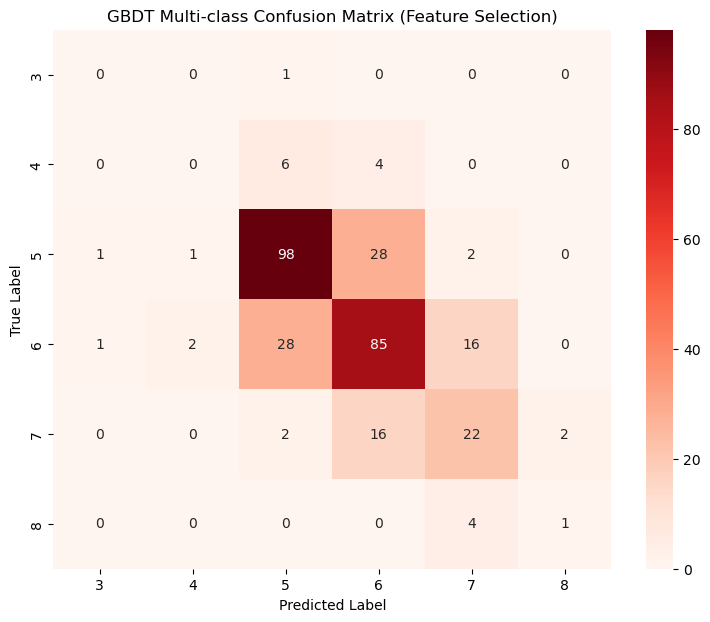

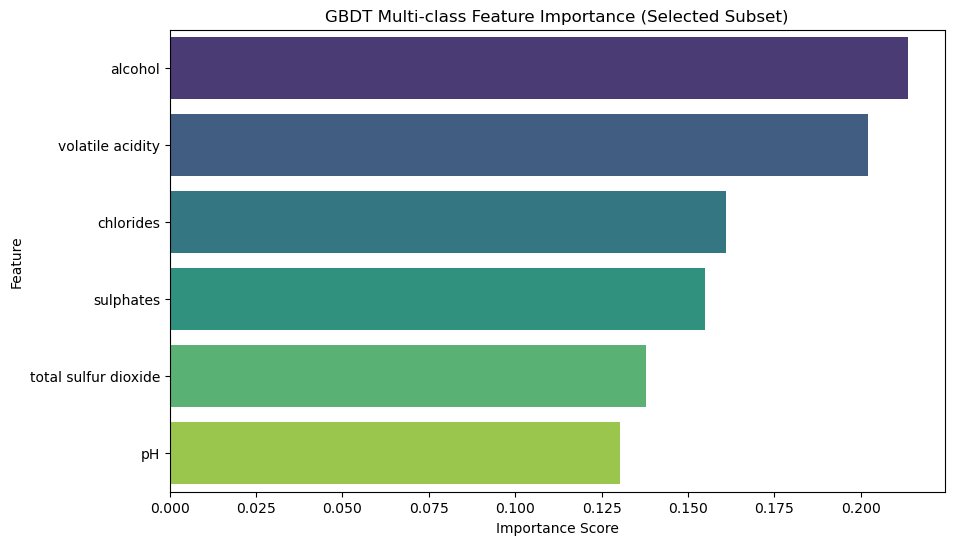

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_selection import SelectFromModel

df = pd.read_csv("../data/winequality-red_sep.csv") 

X = df.drop('quality', axis=1) 
y = df['quality']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_gs, _, y_train_gs, _ = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

best_params = {
    'n_estimators': 500, 
    'max_depth': 6, 
    'learning_rate': 0.1,
    'subsample': 0.8,
    'min_samples_leaf': 1
}

temp_gbdt = GradientBoostingClassifier(
    **best_params, 
    random_state=42
)

gs_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_gs)

temp_gbdt.fit(X_train_gs, y_train_gs, sample_weight=gs_sample_weights)

sfm = SelectFromModel(temp_gbdt, threshold='median', prefit=True) 

X_train_selected = sfm.transform(X_train_val)
X_test_selected = sfm.transform(X_test)

selected_features = X.columns[sfm.get_support()]
print(f"Original Feature Count: {X.shape[1]}")
print(f"Selected Feature Count: {X_train_selected.shape[1]}")
print(f"Selected Features: {list(selected_features)}")

X_train_final = X_train_selected
y_train_final = y_train_val 

final_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_final
)

final_gbdt_fs = GradientBoostingClassifier(
    **best_params, 
    random_state=42
)

final_gbdt_fs.fit(X_train_final, y_train_final, sample_weight=final_sample_weights)

y_test_pred = final_gbdt_fs.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

results_list.append(('Feature selection', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('GBDT Multi-class Confusion Matrix (Feature Selection)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(10, 6))
feature_importances = final_gbdt_fs.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis', hue='Feature', legend=False)
plt.title('GBDT Multi-class Feature Importance (Selected Subset)')
plt.xlabel('Importance Score')
plt.show()

# Feature Engineering

Total feature count in the dataset: 14
Accuracy: 0.6781, Macro F1: 0.3368

--- Module 5 ---
Accuracy: 0.6781
Macro F1 Score: 0.3368
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.75      0.72      0.73       130
           6       0.65      0.76      0.70       132
           7       0.64      0.55      0.59        42
           8       0.00      0.00      0.00         5

    accuracy                           0.68       320
   macro avg       0.34      0.34      0.34       320
weighted avg       0.65      0.68      0.66       320



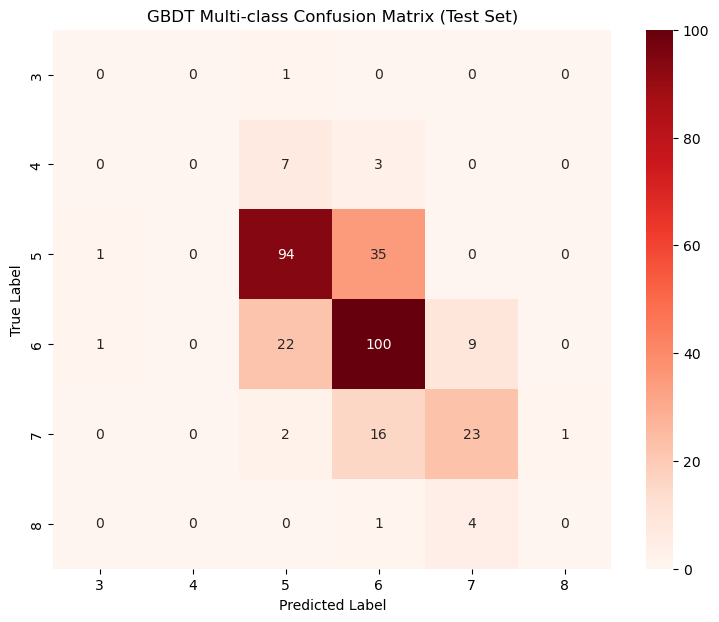

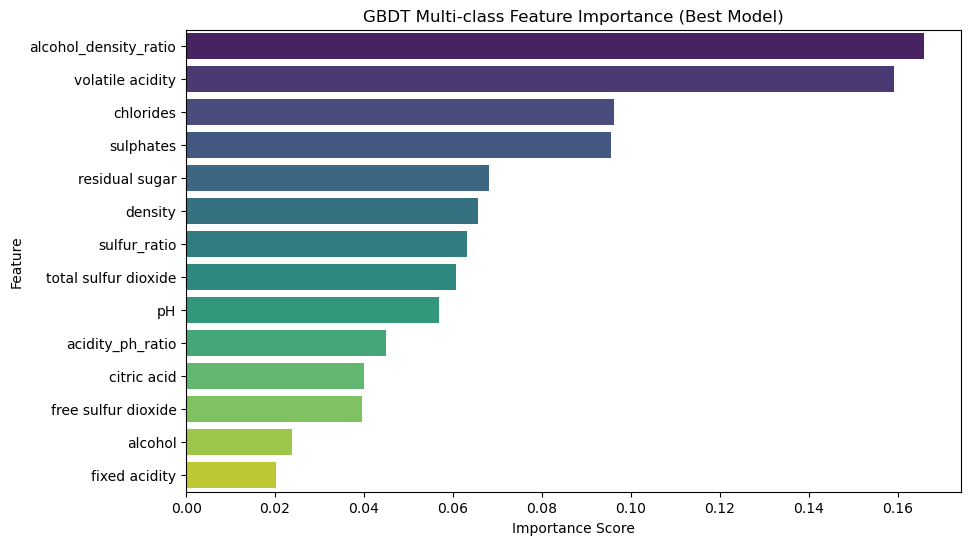

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

df = pd.read_csv("../data/winequality-red_sep.csv") 

df['alcohol_density_ratio'] = df['alcohol'] / df['density']
df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']
df['acidity_ph_ratio'] = df['fixed acidity'] / df['pH']

X = df.drop('quality', axis=1) 
y = df['quality']
print(f"Total feature count in the dataset: {X.shape[1]}")

X_train_final, X_test, y_train_final, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

final_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_final
)

best_params = {
    'n_estimators': 500, 
    'max_depth': 6, 
    'learning_rate': 0.1,
    'subsample': 0.8,
    'min_samples_leaf': 1
}

final_gbdt_fe = GradientBoostingClassifier(
    **best_params, 
    random_state=42
)

final_gbdt_fe.fit(X_train_final, y_train_final, sample_weight=final_sample_weights)

y_test_pred = final_gbdt_fe.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

results_list.append(('Feature Engineering', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")

print("\n--- Module 5 ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}") 
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('GBDT Multi-class Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(10, 6))
feature_importances = final_gbdt_fe.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis', hue='Feature', legend=False)
plt.title('GBDT Multi-class Feature Importance (Best Model)')
plt.xlabel('Importance Score')
plt.show()

# Feature Engineering + hyperparameter tuning

Total feature count in the dataset: 14
Grid Search Training Set (60%): 959 samples
Final Test Set (20%): 320 samples
Multi-class Label Distribution (60%): 
quality
3      8
4     29
5    398
6    391
7    124
8      9
Name: count, dtype: int64

--- GBDT Grid Search Started ---
Total Theoretical Candidate Combinations: 243
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

 Grid Search best parameters combinations): {'gbdt__learning_rate': 0.05, 'gbdt__max_depth': 6, 'gbdt__min_samples_leaf': 3, 'gbdt__n_estimators': 100, 'gbdt__subsample': 0.6}
 Best validation score: 0.6350

--- Training Final Multi-class Model on Combined Dataset of 1279 samples ---
Accuracy: 0.6969, Macro F1: 0.3571
Accuracy: 0.6969
Macro F1 Score: 0.3571
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.77      0.74      0.75       130
           

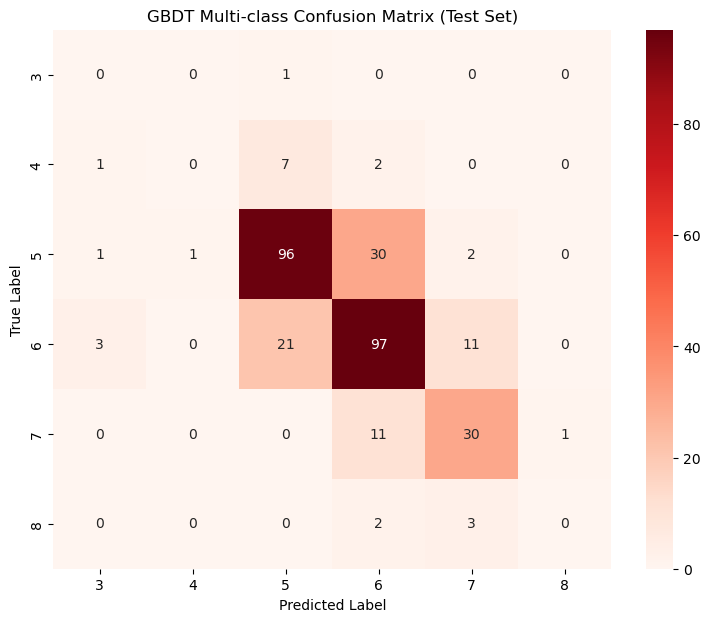

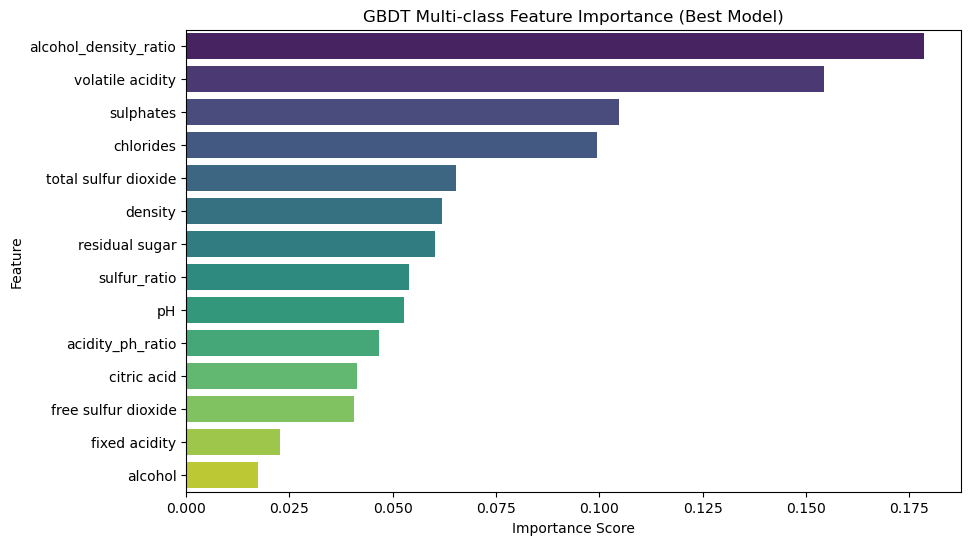

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score 
from sklearn.utils.class_weight import compute_sample_weight

try:
    df = pd.read_csv("../data/winequality-red_sep.csv")
except FileNotFoundError:
    print("ERROR: Please ensure that the path of the data file is correct.")

df['alcohol_density_ratio'] = df['alcohol'] / df['density']
df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']
df['acidity_ph_ratio'] = df['fixed acidity'] / df['pH']

X = df.drop('quality', axis=1) 
y = df['quality'] 
print(f"Total feature count in the dataset: {X.shape[1]}")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_gs, X_val, y_train_gs, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(f"Grid Search Training Set (60%): {len(X_train_gs)} samples")
print(f"Final Test Set (20%): {len(X_test)} samples")
print(f"Multi-class Label Distribution (60%): \n{y_train_gs.value_counts().sort_index()}")


gs_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_gs
)

gbdt_pipeline = Pipeline([
    ('gbdt', GradientBoostingClassifier(random_state=42)) 
])

param_grid = {
    'gbdt__n_estimators': [100, 300, 500],
    'gbdt__learning_rate': [0.01, 0.05, 0.1],
    'gbdt__max_depth': [4, 5, 6],         
    'gbdt__min_samples_leaf': [1, 3, 5], 
    'gbdt__subsample': [0.6, 0.8, 1.0],       
}

total_candidates = np.prod([len(v) for v in param_grid.values()])
print(f"\n--- GBDT Grid Search Started ---")
print(f"Total Theoretical Candidate Combinations: {total_candidates}")

grid_search = GridSearchCV(
    estimator=gbdt_pipeline, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=5, 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_gs, y_train_gs, gbdt__sample_weight=gs_sample_weights)


best_params_raw = grid_search.best_params_
best_score = grid_search.best_score_
print(f"\n Grid Search best parameters combinations): {best_params_raw}")
print(f" Best validation score: {best_score:.4f}")

print(f"\n--- Training Final Multi-class Model on Combined Dataset of {len(X_train_val)} samples ---")

final_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_val
)

final_gbdt = GradientBoostingClassifier(
    n_estimators=best_params_raw['gbdt__n_estimators'],     
    learning_rate=best_params_raw['gbdt__learning_rate'],    
    max_depth=best_params_raw['gbdt__max_depth'],
    subsample=best_params_raw['gbdt__subsample'],
    min_samples_leaf=best_params_raw['gbdt__min_samples_leaf'],
    random_state=42
)

final_gbdt.fit(X_train_val, y_train_val, sample_weight=final_sample_weights)

y_test_pred = final_gbdt.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

results_list.append(('Feature Engineering + hyperparameter tuning', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('GBDT Multi-class Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show() 

plt.figure(figsize=(10, 6))
feature_importances = final_gbdt.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis', hue='Feature', legend=False)
plt.title('GBDT Multi-class Feature Importance (Best Model)')
plt.xlabel('Importance Score')
plt.show()

# Bagging 

Accuracy: 0.6531, Macro F1: 0.3920
Accuracy: 0.6531
Macro F1 Score: 0.3920
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.72      0.71       136
           6       0.62      0.68      0.65       128
           7       0.61      0.57      0.59        40
           8       0.50      0.33      0.40         3

    accuracy                           0.65       320
   macro avg       0.41      0.38      0.39       320
weighted avg       0.63      0.65      0.64       320



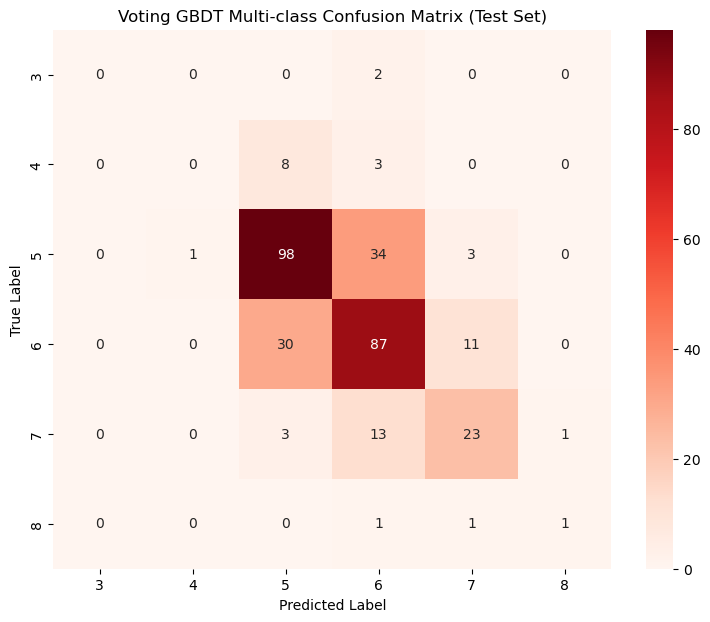


--- Voting GBDT Feature Importance (Averaged) ---


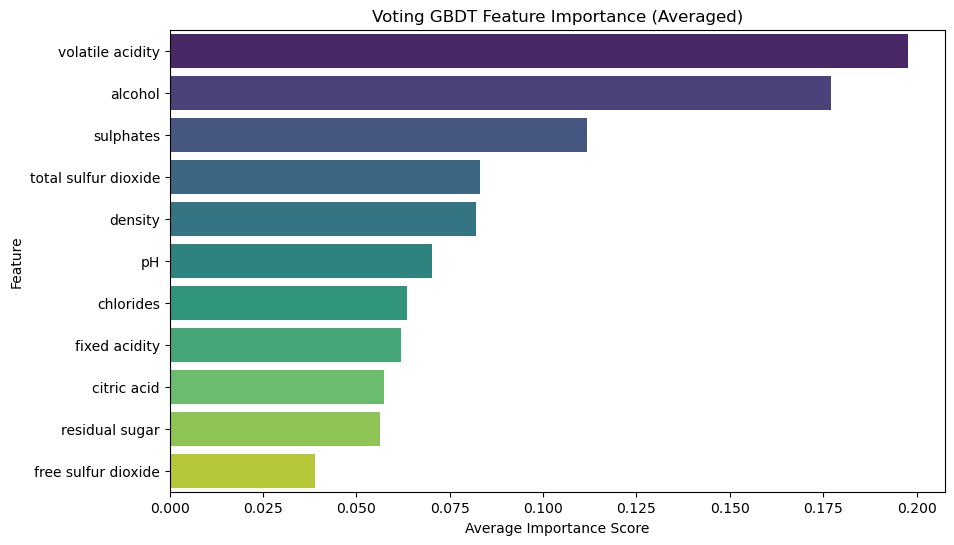

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier 
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight
import sklearn

sklearn.set_config(enable_metadata_routing=True)

try:
    df = pd.read_csv("../data/winequality-red_sep.csv") 
except FileNotFoundError:
    print("ERROR: Please ensure that the path of the data file is correct.")
    exit() 


X = df.drop('quality', axis=1) 
y = df['quality']

# Train_Val (80%) vs Test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

final_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_val
)

gbdt_1 = GradientBoostingClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1, subsample=0.6, min_samples_leaf=1, random_state=42
)
gbdt_2 = GradientBoostingClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05, subsample=0.8, min_samples_leaf=1, random_state=101
)
gbdt_3 = GradientBoostingClassifier(
    n_estimators=500, max_depth=7, learning_rate=0.15, subsample=0.7, min_samples_leaf=1, random_state=202
)
gbdt_4 = GradientBoostingClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.12, subsample=0.7, min_samples_leaf=2, random_state=303
)
gbdt_5 = GradientBoostingClassifier(
    n_estimators=450, max_depth=5, learning_rate=0.08, subsample=0.8, min_samples_leaf=1, random_state=404
)


gbdt_1.set_fit_request(sample_weight=True)
gbdt_2.set_fit_request(sample_weight=True)
gbdt_3.set_fit_request(sample_weight=True)
gbdt_4.set_fit_request(sample_weight=True)
gbdt_5.set_fit_request(sample_weight=True)

# VotingClassifier
final_voting_gbdt = VotingClassifier(
    estimators=[('gbdt1', gbdt_1), ('gbdt2', gbdt_2), ('gbdt3', gbdt_3), ('gbdt4', gbdt_4), ('gbdt5', gbdt_5)],
    voting='soft',
    n_jobs=-1
)

final_voting_gbdt.fit(
    X_train_val,
    y_train_val,
    sample_weight=final_sample_weights  
)


y_test_pred = final_voting_gbdt.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

results_list.append(('Bagging', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}") 
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Voting GBDT Multi-class Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show() 

print("\n--- Voting GBDT Feature Importance (Averaged) ---")

importances = np.array([
    estimator.feature_importances_ 
    for estimator in final_voting_gbdt.estimators_
])
avg_importances = np.mean(importances, axis=0)

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': avg_importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis', hue='Feature', legend=False)
plt.title('Voting GBDT Feature Importance (Averaged)')
plt.xlabel('Average Importance Score')
plt.show()

# OneVsRestClassifier

Accuracy: 0.6687, Macro F1: 0.3398
Accuracy: 0.6687
Macro F1 Score: 0.3398
Classification Report (OvR):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.75      0.73       130
           6       0.65      0.67      0.66       132
           7       0.64      0.67      0.65        42
           8       0.00      0.00      0.00         5

    accuracy                           0.67       320
   macro avg       0.33      0.35      0.34       320
weighted avg       0.64      0.67      0.65       320



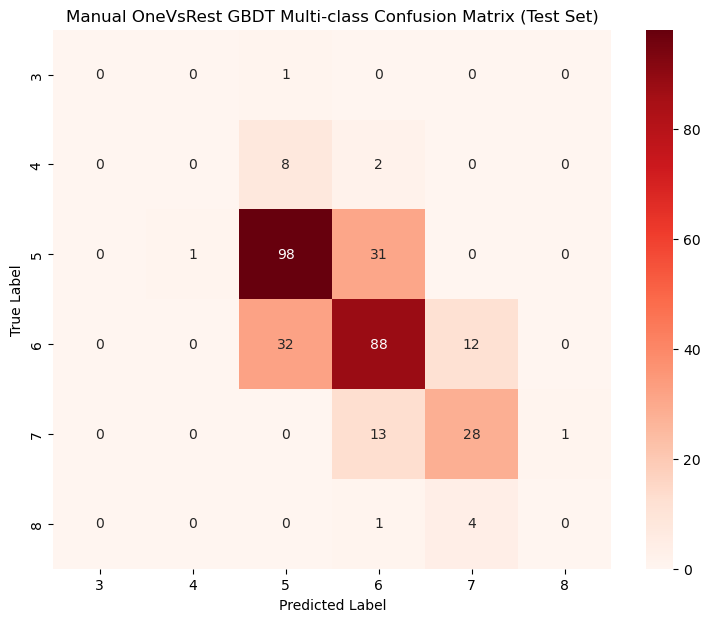

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight

best_params = {
    'n_estimators': 100, 
    'max_depth': 6, 
    'learning_rate': 0.05,
    'subsample': 0.6,
    'min_samples_leaf': 3
}

try:
    df = pd.read_csv("../data/winequality-red_sep.csv") 
except FileNotFoundError:
    print("ERROR: Please ensure that the path of the data file is correct.")
    exit() 

df['alcohol_density_ratio'] = df['alcohol'] / df['density']
df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']
df['acidity_ph_ratio'] = df['fixed acidity'] / df['pH']

X = df.drop('quality', axis=1)
y = df['quality']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
unique_classes = sorted(y_train_val.unique())

ovr_estimators = [] 

for class_label in unique_classes:
    y_binary = (y_train_val == class_label).astype(int)
    binary_weights = compute_sample_weight(
        class_weight='balanced',
        y=y_binary
    )
    
    gbdt_clf = GradientBoostingClassifier(
        **best_params, 
        random_state=42
    )
    
    gbdt_clf.fit(X_train_val, y_binary, sample_weight=binary_weights)
    
    ovr_estimators.append((f'clf_{class_label}', gbdt_clf))

test_proba = []
for _, clf in ovr_estimators:
    proba = clf.predict_proba(X_test)[:, 1] 
    test_proba.append(proba)

test_proba_array = np.array(test_proba).T 
y_test_pred_indices = np.argmax(test_proba_array, axis=1)
y_test_pred = np.array(unique_classes)[y_test_pred_indices]
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

results_list.append(('OneVsRestClassifier', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}") 
print("Classification Report (OvR):")

print(classification_report(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Manual OneVsRest GBDT Multi-class Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Random Oversampling

Current number of features: 14
Original training set (80%) size: 1279
Original class distribution:
quality
3      9
4     43
5    551
6    506
7    157
8     13
Name: count, dtype: int64

--- Executing Random Oversampling  ---
Total oversampled training samples: 3306
Oversampled class distribution:
quality
3    551
4    551
5    551
6    551
7    551
8    551
Name: count, dtype: int64
Accuracy: 0.6375, Macro F1: 0.3668
Accuracy: 0.6375
Macro F1 Score: 0.3668
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.33      0.20      0.25        10
           5       0.68      0.78      0.73       130
           6       0.67      0.55      0.60       132
           7       0.58      0.67      0.62        42
           8       0.00      0.00      0.00         5

    accuracy                           0.64       320
   macro avg       0.38      0.37      0.37       320
weighted avg       0.64   

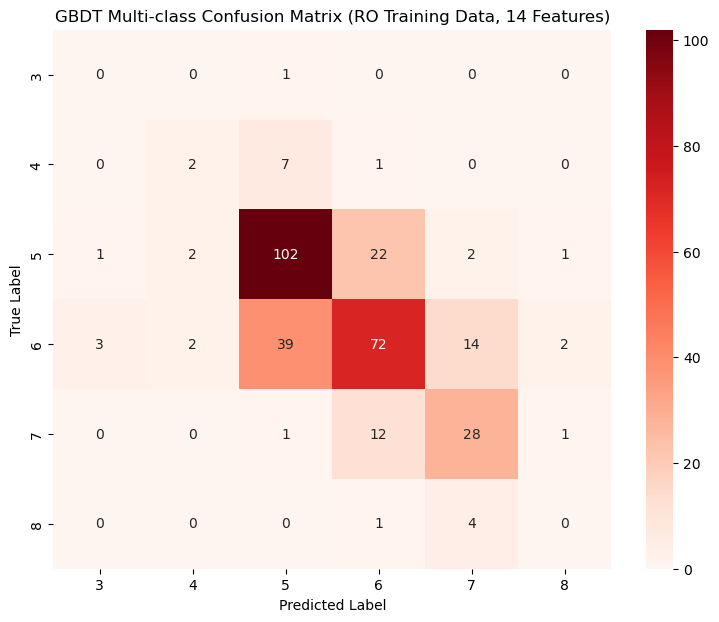


--- GBDT Feature Importance ---


C:\Users\lenovo\AppData\Local\Temp\ipykernel_34476\1596438807.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp, palette="viridis")


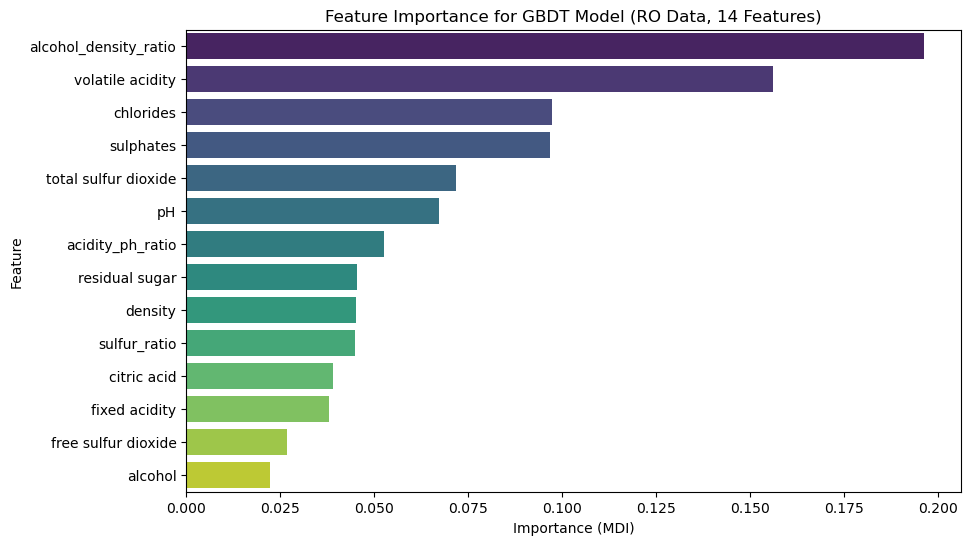

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight

# Fixed random seed
RANDOM_STATE = 42

best_params = {
    'n_estimators': 100, 
    'max_depth': 6, 
    'learning_rate': 0.05,
    'subsample': 0.6,
    'min_samples_leaf': 3
}

try:
    df = pd.read_csv("../data/winequality-red_sep.csv") 
except FileNotFoundError:
    print("ERROR: Please ensure that the path of the data file is correct.")
    exit() 

df['alcohol_density_ratio'] = df['alcohol'] / df['density']
df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']
df['acidity_ph_ratio'] = df['fixed acidity'] / df['pH']

X = df.drop('quality', axis=1) 
y = df['quality']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Current number of features: {X.shape[1]}")
print(f"Original training set (80%) size: {len(X_train_val)}")
print(f"Original class distribution:\n{y_train_val.value_counts().sort_index()}")

print("\n--- Executing Random Oversampling  ---")

df_train = X_train_val.copy()
df_train['quality'] = y_train_val

class_counts = df_train['quality'].value_counts()
target_count = class_counts.max() 
oversampled_frames = []

for label, count in class_counts.items():
    class_df = df_train[df_train['quality'] == label]
    
    if count < target_count:
        oversampled_data = class_df.sample(
            n=target_count,
            replace=True, 
            random_state=RANDOM_STATE
        )
        oversampled_frames.append(oversampled_data)
    else:
        oversampled_frames.append(class_df)

# Concatenate all oversampled data and shuffle
df_oversampled = pd.concat(oversampled_frames, axis=0)
df_oversampled = df_oversampled.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_final_ro = df_oversampled.drop('quality', axis=1)
y_train_final_ro = df_oversampled['quality']

print(f"Total oversampled training samples: {len(X_train_final_ro)}")
print(f"Oversampled class distribution:\n{y_train_final_ro.value_counts().sort_index()}")

final_gbdt_model = GradientBoostingClassifier(
    **best_params, 
    random_state=RANDOM_STATE
)

final_gbdt_model.fit(X_train_final_ro, y_train_final_ro)

y_test_pred = final_gbdt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

results_list.append(('Random Oversampling', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}") 
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('GBDT Multi-class Confusion Matrix (RO Training Data, 14 Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show() 

print("\n--- GBDT Feature Importance ---")

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_gbdt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette="viridis")
plt.title('Feature Importance for GBDT Model (RO Data, 14 Features)')
plt.xlabel('Importance (MDI)')
plt.ylabel('Feature')
plt.show()

# Log Transformed Data

Current number of features: 14
Log transformation completed.

---Training GBDT Model ---
Accuracy: 0.6625, Macro F1: 0.4048
Accuracy: 0.6625
Macro F1 Score: 0.4048
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.72      0.68      0.70       136
           6       0.64      0.73      0.68       128
           7       0.71      0.60      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.66       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.66      0.65       320



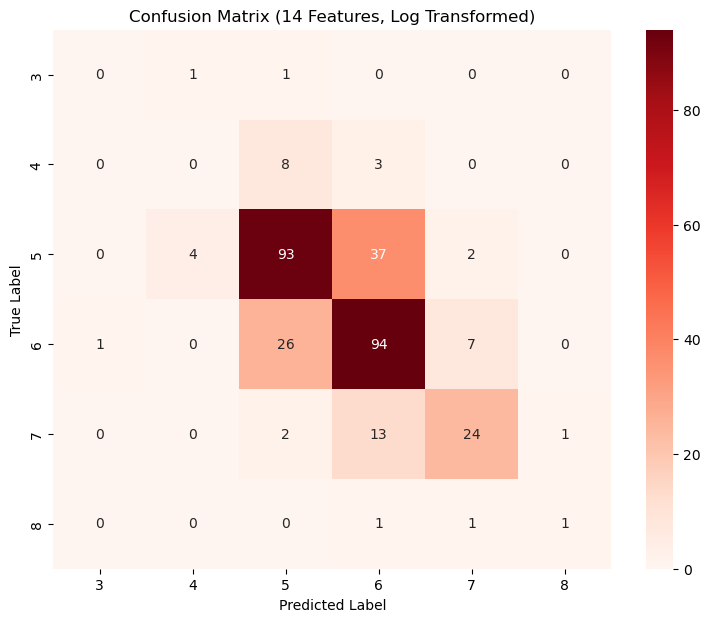

C:\Users\lenovo\AppData\Local\Temp\ipykernel_34476\84198989.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp, palette="viridis")


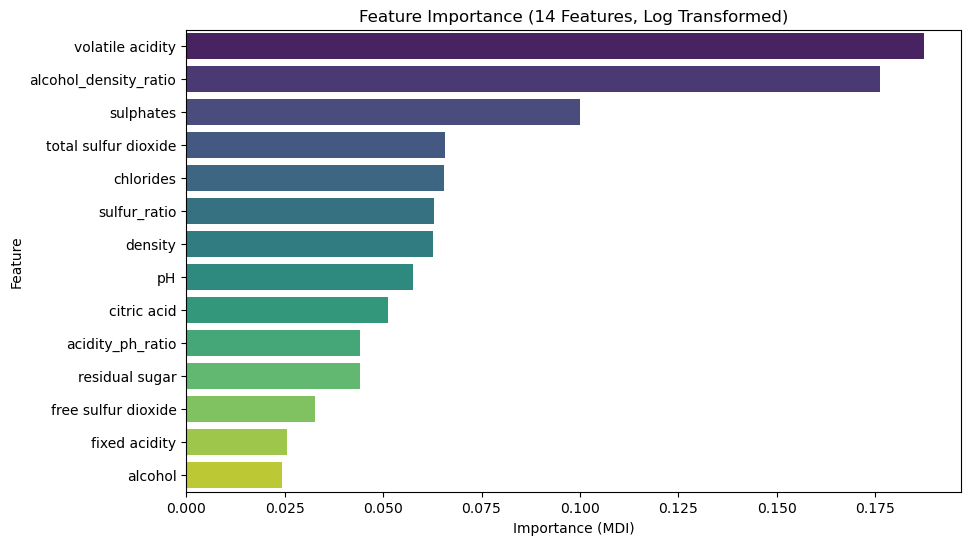

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight 

RANDOM_STATE = 42
best_params = {
    'n_estimators': 100, 
    'max_depth': 6, 
    'learning_rate': 0.05,
    'subsample': 0.6,
    'min_samples_leaf': 3
}

try:
    df = pd.read_csv("../data/winequality-red_sep.csv") 
except FileNotFoundError:
    print("ERROR: Please ensure that the data file is placed in the correct path or environment.")
    exit() 

df['alcohol_density_ratio'] = df['alcohol'] / df['density']
df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']
df['acidity_ph_ratio'] = df['fixed acidity'] / df['pH']

X = df.drop('quality', axis=1) 
y = df['quality']
print(f"Current number of features: {X.shape[1]}")


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

final_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_val)

log_features = ['residual sugar', 'chlorides', 'fixed acidity', 'total sulfur dioxide']
log_features = [col for col in log_features if col in X.columns] 

X_train_final = X_train_val.copy()
X_test_final = X_test.copy()

# Apply log transformation to the specified features
for col in log_features:
    X_train_final[col] = np.log1p(X_train_final[col])
    X_test_final[col] = np.log1p(X_test_final[col])
    
print("Log transformation completed.")

print("\n---Training GBDT Model ---")

final_gbdt_model = GradientBoostingClassifier(
    **best_params, 
    random_state=RANDOM_STATE
)

final_gbdt_model.fit(X_train_final, y_train_val, sample_weight=final_sample_weights)
y_test_pred = final_gbdt_model.predict(X_test_final)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)


results_list.append(('Log Transformed Data', accuracy, macro_f1))

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}") 
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds', 
    xticklabels=class_labels, 
    yticklabels=class_labels
)
plt.title('Confusion Matrix (14 Features, Log Transformed)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show() 

feature_imp = pd.DataFrame({'Feature': X.columns, 'Importance': final_gbdt_model.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette="viridis")
plt.title('Feature Importance (14 Features, Log Transformed)')
plt.xlabel('Importance (MDI)')
plt.ylabel('Feature')
plt.show()

# Scaling

 Accuracy: 0.6781, Macro F1: 0.3455
Accuracy: 0.6781
Macro F1 Score: 0.3455
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.74      0.76      0.75       130
           6       0.68      0.68      0.68       132
           7       0.62      0.67      0.64        42
           8       0.00      0.00      0.00         5

    accuracy                           0.68       320
   macro avg       0.34      0.35      0.35       320
weighted avg       0.66      0.68      0.67       320



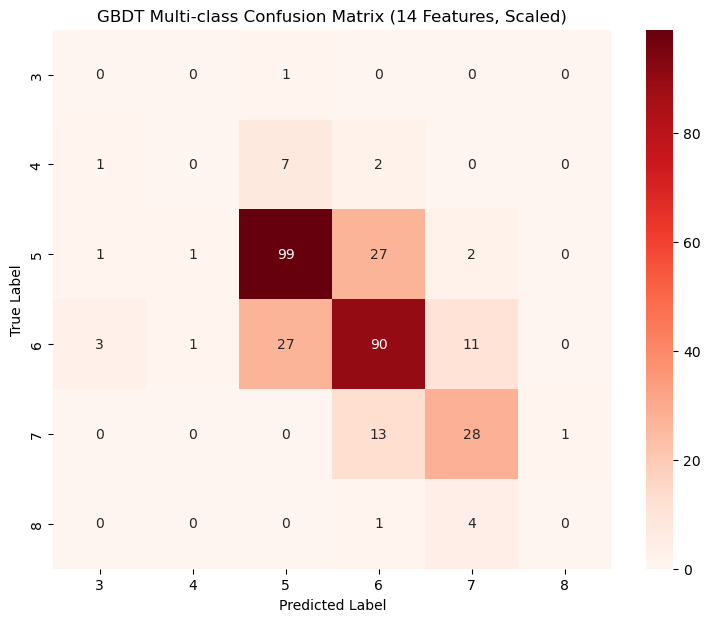


--- GBDT Feature Importance ---


C:\Users\lenovo\AppData\Local\Temp\ipykernel_34476\1851365168.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp, palette="viridis")


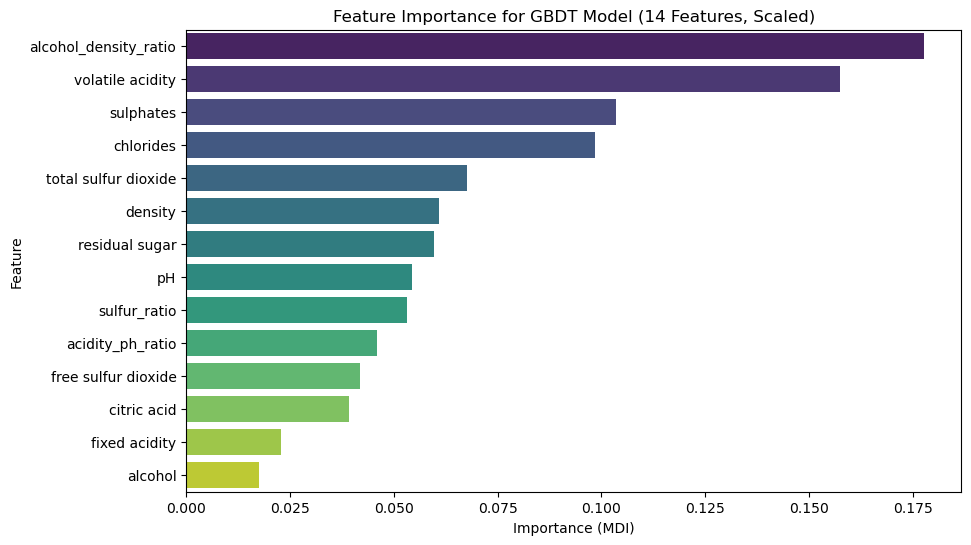

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight 
from sklearn.preprocessing import RobustScaler 


best_params = {
    'n_estimators': 100, 
    'max_depth': 6, 
    'learning_rate': 0.05,
    'subsample': 0.6,
    'min_samples_leaf': 3
}

try:
    df = pd.read_csv("../data/winequality-red_sep.csv") 
except FileNotFoundError:
    print("ERROR: Please ensure that the data file is placed in the correct path: ../data/winequality-red_sep.csv")
    exit() 

df['alcohol_density_ratio'] = df['alcohol'] / df['density']
df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']
df['acidity_ph_ratio'] = df['fixed acidity'] / df['pH']

X = df.drop('quality', axis=1)
y = df['quality'] 

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

final_sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_val
)


scaler = RobustScaler()

X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

X_train_final = pd.DataFrame(X_train_val_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)


final_gbdt_model = GradientBoostingClassifier(
    **best_params, 
    random_state=42
)

final_gbdt_model.fit(X_train_final, y_train_val, sample_weight=final_sample_weights)

y_test_pred = final_gbdt_model.predict(X_test_final)
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

results_list.append(('Scaling', accuracy, macro_f1))

print(f" Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}") 
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_test_pred)
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('GBDT Multi-class Confusion Matrix (14 Features, Scaled)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show() 

print("\n--- GBDT Feature Importance ---")

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_gbdt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette="viridis")
plt.title('Feature Importance for GBDT Model (14 Features, Scaled)')
plt.xlabel('Importance (MDI)')
plt.ylabel('Feature')
plt.show()